# Llama with LoRA

This notebook uses an off the shelf Llama model slightly trained with LoRa to classify a news article into one of five bias labels. We freeze Llama and add a classification head to create a baseline Llama implementation before going on to LoRA in the next notebook. 

# Import

In [1]:
import os
import pandas as pd
import numpy as np

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, make_scorer, f1_score, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup
from torch.optim import AdamW
from tqdm import tqdm
from peft import LoraConfig, get_peft_model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

# if using Google Colab, mount Google Drive
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    train_path = '/content/drive/MyDrive/CS5242Project/train_preprocessed.csv'
    test_path  = '/content/drive/MyDrive/CS5242Project/test_preprocessed.csv'
else:
    train_path = 'transformers_train_preprocessed.csv'
    test_path  = 'transformers_test_preprocessed.csv'

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

train['cleaned_text'] = train['cleaned_text'].astype(str)
test['cleaned_text'] = test['cleaned_text'].astype(str)

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train['Bias'])
y_test  = label_encoder.transform(test['Bias'])
num_classes = len(label_encoder.classes_)

model_id = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
tokenizer = AutoTokenizer.from_pretrained(model_id)

class NewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])
        encodings = self.tokenizer(
            text,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids": encodings["input_ids"].squeeze(0),
            "attention_mask": encodings["attention_mask"].squeeze(0),
            "labels": torch.tensor(label)
        }

/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


In [2]:
torch.manual_seed(42)
np.random.seed(42)

In [3]:
train_dataset = NewsDataset(train['cleaned_text'], y_train, tokenizer)
test_dataset = NewsDataset(test['cleaned_text'], y_test, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8)

In [4]:
class LlamaClassifier(nn.Module):
    def __init__(self, model_id, num_classes, lora_r=8, lora_alpha=16, lora_dropout=0.1):
        super().__init__()
        self.llama = AutoModel.from_pretrained(model_id)
        self.tokenizer = AutoTokenizer.from_pretrained(model_id)

        lora_config = LoraConfig(
            r=lora_r,
            lora_alpha=lora_alpha,
            target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],  
            lora_dropout=lora_dropout,
            bias="none",
            task_type="SEQ_CLS"  # sequence classification
        )
        self.llama = get_peft_model(self.llama, lora_config)
        
        self.classifier = nn.Linear(self.llama.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask=None):
        outputs = self.llama(input_ids=input_ids, attention_mask=attention_mask)
        hidden_states = outputs.last_hidden_state  # (batch_size, seq_len, hidden_size)
         
        pooled = hidden_states.mean(dim=1)  # Mean pooling, same as bert
        logits = self.classifier(pooled)
        return logits

In [5]:
model = LlamaClassifier(model_id, num_classes)
model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
num_epochs = 1
total_steps = len(train_loader) * num_epochs
warmup_steps = int(0.1 * total_steps)
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)
class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

'NoneType' object has no attribute 'cadam32bit_grad_fp32'


/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/bitsandbytes/cextension.py:34: UserWarning: The installed version of bitsandbytes was compiled without GPU support. 8-bit optimizers, 8-bit multiplication, and GPU quantization are unavailable.
  warn("The installed version of bitsandbytes was compiled without GPU support. "


In [6]:
# count number of trainable parameters
trainable_params = 0
all_params = 0
for name, param in model.named_parameters():
    all_params += param.numel()
    if param.requires_grad:
        trainable_params += param.numel()

print(f"Trainable parameters: {trainable_params:,} ({100 * trainable_params / all_params:.2f}% of all parameters)")

Trainable parameters: 2,263,045 (0.22% of all parameters)


We choose the smallest Llama model because our compute power is limited by our local laptop. 

In [7]:
for epoch in range(num_epochs):
    # — Training
    model.train()
    total_train_loss = 0
    for batch in train_loader:
        # Move batch to device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Forward pass
        logits = model(input_ids, attention_mask=attention_mask)
        loss = criterion(logits, labels)

        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) #gradient clipping
        optimizer.step()
        scheduler.step()

        optimizer.zero_grad()

        total_train_loss += loss.item()
    avg_train_loss = total_train_loss / len(train_loader)
    print(f"Epoch {epoch+1} →  training loss: {avg_train_loss:.4f}")


Epoch 1 →  training loss: 1.5781


In [13]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score 
model.eval()
all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids     = batch["input_ids"].to(device)
        attention_mask= batch["attention_mask"].to(device)
        labels        = batch["labels"].to(device)

        logits = model(input_ids, attention_mask=attention_mask)
        preds  = torch.argmax(logits, dim=-1)
        probs  = torch.softmax(logits, dim=-1)

        all_labels.extend(labels.cpu().numpy())    # flat list of true labels
        all_preds.extend(preds.cpu().numpy())     # flat list of preds
        all_probs.append(probs.cpu().numpy())     # list of (batch_size, n_classes)


In [14]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score 
model.eval()
all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids     = batch["input_ids"].to(device)
        attention_mask= batch["attention_mask"].to(device)
        labels        = batch["labels"].to(device)

        logits = model(input_ids, attention_mask=attention_mask)
        preds  = torch.argmax(logits, dim=-1)
        probs  = torch.softmax(logits, dim=-1)

        all_labels.extend(labels.cpu().numpy())    # flat list of true labels
        all_preds.extend(preds.cpu().numpy())     # flat list of preds
        all_probs.append(probs.cpu().numpy())     # list of (batch_size, n_classes)


In [15]:
y_true  = np.array(all_labels)
y_pred  = np.array(all_preds)
y_score = np.concatenate(all_probs, axis=0)  

In [16]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')
print(f"Epoch {epoch+1} — Eval accuracy: {acc:.4f}; F1: {f1:.4f}; Precision: {precision:.4f}; Recall: {recall:.4f}")


Epoch 1 — Eval accuracy: 0.3432; F1: 0.3764; Precision: 0.4473; Recall: 0.3432


In [17]:
from sklearn.metrics import classification_report
print(classification_report(all_labels, all_preds, target_names=label_encoder.classes_, digits=4))

              precision    recall  f1-score   support

      center     0.1452    0.2195    0.1748        41
   lean left     0.1972    0.2295    0.2121        61
  lean right     0.1639    0.2703    0.2041        37
        left     0.7101    0.4414    0.5444       222
       right     0.1810    0.2500    0.2099        76

    accuracy                         0.3432       437
   macro avg     0.2795    0.2821    0.2691       437
weighted avg     0.4473    0.3432    0.3764       437



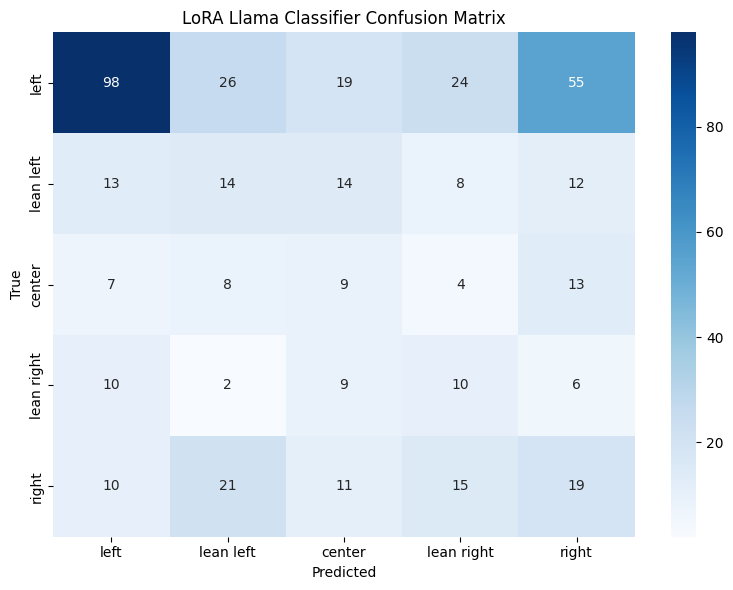

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
#labels = label_encoder.classes_
label_order = ['left', 'lean left', 'center', 'lean right', 'right']
label_indices = [np.where(label_encoder.classes_ == label)[0][0] for label in label_order]

cm = confusion_matrix(all_labels, all_preds, labels=label_indices)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_order, yticklabels=label_order)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('LoRA Llama Classifier Confusion Matrix')
plt.tight_layout()
plt.show()

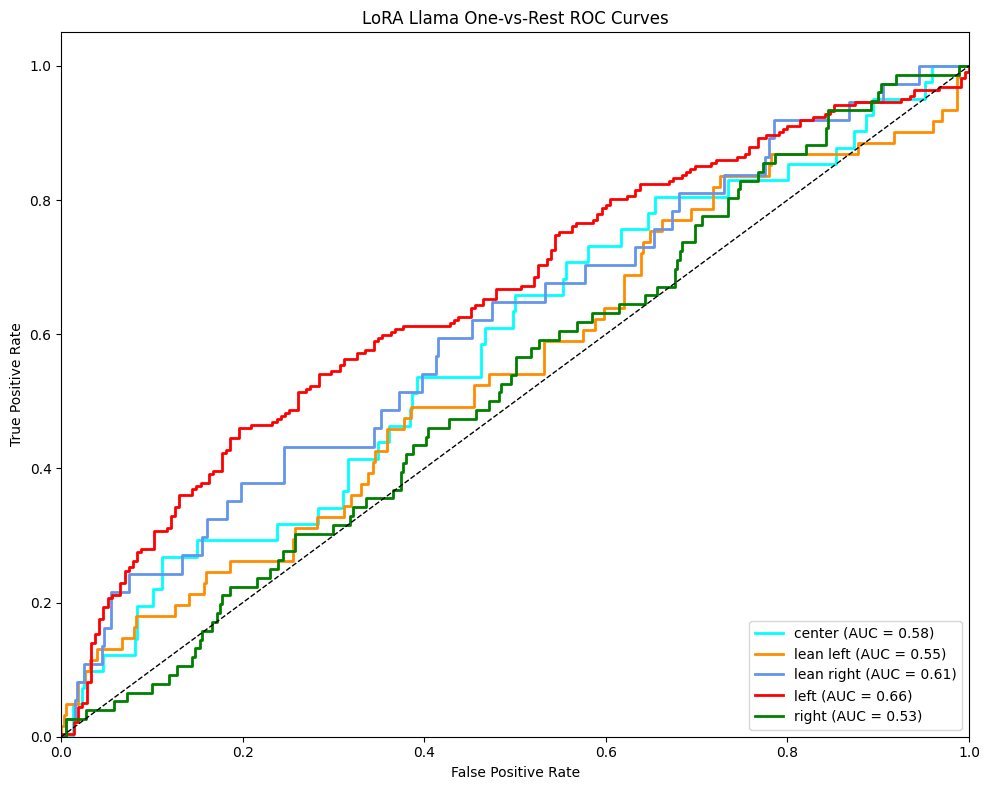

In [19]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
from itertools import cycle

classes = label_encoder.classes_
y_test_binarized = label_binarize(y_true, classes=np.arange(len(classes)))

fpr, tpr, roc_auc = {}, {}, {}
for i, c in enumerate(classes):
    fpr[c], tpr[c], _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
    roc_auc[c]        = roc_auc_score(y_test_binarized[:, i], y_score[:, i])

# Plot
plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red', 'green'])
for c, color in zip(classes, colors):
    plt.plot(fpr[c], tpr[c], color=color, lw=2,
             label=f'{c} (AUC = {roc_auc[c]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim(0, 1); plt.ylim(0, 1.05)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('LoRA Llama One-vs-Rest ROC Curves')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()